In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('train_data.csv')
data.head()

,Exam1,Exam2,Pass
0,37.45,3.14,0
1,95.07,63.64,1
2,73.20,31.44,1
3,59.87,50.86,1
4,15.60,90.76,1


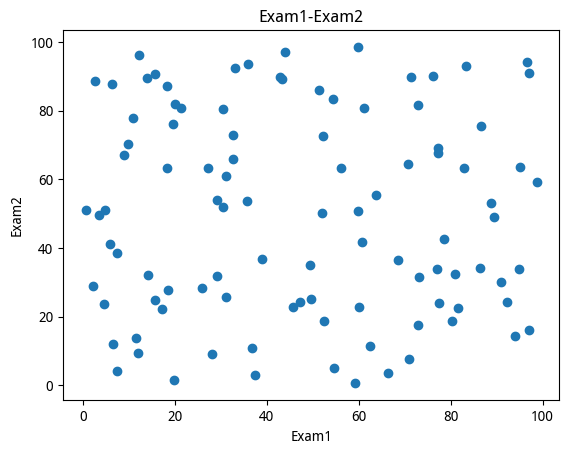

In [2]:
%matplotlib inline
from matplotlib import pyplot as plt
figl=plt.figure()
plt.scatter(data.loc[:,'Exam1'],data.loc[:,'Exam2'])
plt.title('Exam1-Exam2') 
plt.xlabel('Exam1') 
plt.ylabel('Exam2')
plt.show()

In [3]:
mask=data.loc[:,'Pass']==1
print(mask)

0     False
1      True
2      True
3      True
4      True
      ...  
95    False
96     True
97     True
98     True
99     True
Name: Pass, Length: 100, dtype: bool


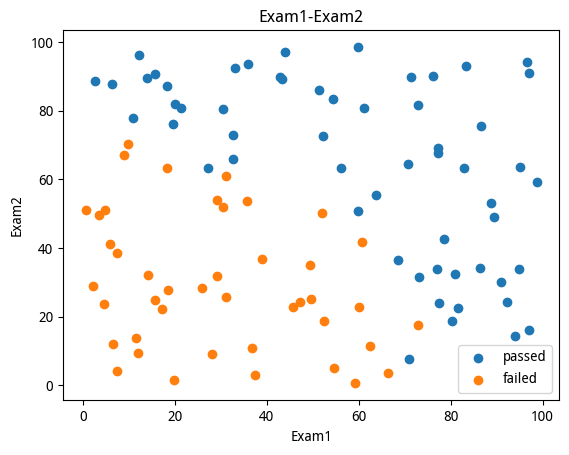

In [4]:
fig2=plt.figure()
passed=plt.scatter(data.loc[:,'Exam1'][mask],data.loc[:,'Exam2'][mask])
failed=plt.scatter(data.loc[:,'Exam1'][~mask],data.loc[:,'Exam2'][~mask])
plt.title('Exam1-Exam2') 
plt.xlabel('Exam1') 
plt.ylabel('Exam2')
plt.legend((passed,failed),('passed','failed'))
plt.show()

In [5]:
X=data.drop(['Pass'],axis=1)
y=data.loc[:,'Pass']
X1=data.loc[:,'Exam1']
X2=data.loc[:,'Exam2']
X.head()

,Exam1,Exam2
0,37.45,3.14
1,95.07,63.64
2,73.20,31.44
3,59.87,50.86
4,15.60,90.76


In [6]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
LR.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
y_predict=LR.predict(X)
print(y_predict)

[0 1 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 1 1 0
 0 1 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1
 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1]


In [8]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y,y_predict)
print(accuracy)

0.96


In [9]:
feature_names = ['Exam1', 'Exam2']
y_test_1=pd.DataFrame([[70,65]],columns=feature_names)
y_test=LR.predict(y_test_1)
print('passed'if y_test==1 else 'failed')

passed


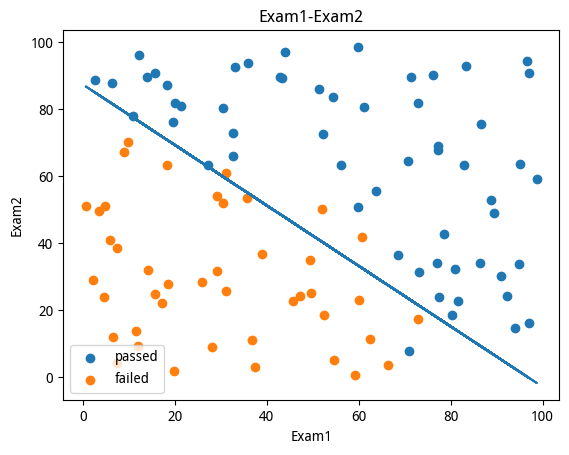

In [10]:
theta1,theta2=LR.coef_[0][0],LR.coef_[0][1]
theta0=LR.intercept_
X2_new=-(theta0+theta1*X1)/theta2
plt.figure(fig2)
plt.plot(X1,X2_new)
plt.show()

In [11]:
X1_2=X1*X1
X2_2=X2*X2
X1_X2=X1*X2

In [12]:
X_new= {'X1':X1, 'X2':X2, 'X1_2':X1_2, 'X2_2':X2_2, 'X1_X2':X1_X2}
X_new=pd.DataFrame(X_new)
print(X_new)

       X1     X2       X1_2       X2_2      X1_X2
0   37.45   3.14  1402.5025     9.8596   117.5930
1   95.07  63.64  9038.3049  4050.0496  6050.2548
2   73.20  31.44  5358.2400   988.4736  2301.4080
3   59.87  50.86  3584.4169  2586.7396  3044.9882
4   15.60  90.76   243.3600  8237.3776  1415.8560
..    ...    ...        ...        ...        ...
95  49.38  34.92  2438.3844  1219.4064  1724.3496
96  52.27  72.60  2732.1529  5270.7600  3794.8020
97  42.75  89.71  1827.5625  8047.8841  3835.1025
98   2.54  88.71     6.4516  7869.4641   225.3234
99  10.79  77.99   116.4241  6082.4401   841.5121

[100 rows x 5 columns]


In [13]:
LR2=LogisticRegression(max_iter=1000)
LR2.fit(X_new,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y2_predict=LR2.predict(X_new)
accuracy2=accuracy_score(y,y2_predict)
accuracy2

0.99

In [15]:
X1_new=X1.sort_values()
print(X1,X1_new)

0     37.45
1     95.07
2     73.20
3     59.87
4     15.60
      ...  
95    49.38
96    52.27
97    42.75
98     2.54
99    10.79
Name: Exam1, Length: 100, dtype: float64 72     0.55
10     2.06
98     2.54
42     3.44
58     4.52
      ...  
1     95.07
34    96.56
50    96.96
11    96.99
69    98.69
Name: Exam1, Length: 100, dtype: float64


/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


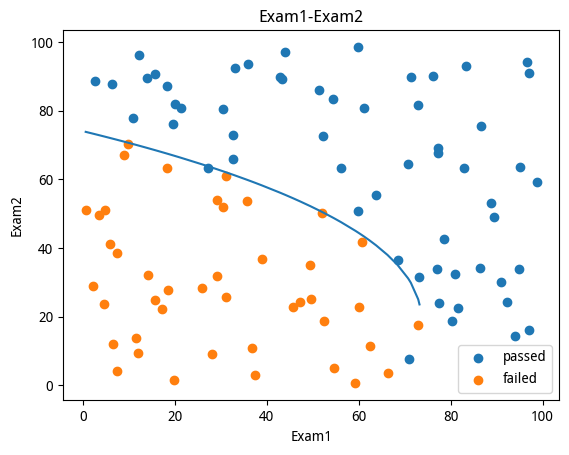

In [16]:
theta1,theta2,theta3,theta4,theta5=LR2.coef_[0][0],LR2.coef_[0][1],LR2.coef_[0][2],LR2.coef_[0][3],LR2.coef_[0][4]
theta0=LR2.intercept_
a=theta4
b=theta5*X1_new+theta2
c=theta0+theta1*X1_new+theta3*X1_new*X1_new
X2_new=(-b+np.sqrt(b*b-4*a*c))/(2*a)

fig3=plt.figure()
plt.plot(X1_new,X2_new)
passed=plt.scatter(data.loc[:,'Exam1'][mask],data.loc[:,'Exam2'][mask])
failed=plt.scatter(data.loc[:,'Exam1'][~mask],data.loc[:,'Exam2'][~mask])
plt.title('Exam1-Exam2') 
plt.xlabel('Exam1') 
plt.ylabel('Exam2')
plt.legend((passed,failed),('passed','failed'))
plt.show()